Download Dataset from Kaggle


In [1]:
import kagglehub
import os

kagglehub.login()

path = kagglehub.competition_download("playground-series-s6e5")

train_csv_path = os.path.join(path, "train.csv")
test_csv_path = os.path.join(path, "test.csv")
sample_submission_path = os.path.join(path, "sample_submission.csv")

Import Required Libraries


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Install Dependencies

This cell automatically detects your GPU and installs the correct version of PyTorch with CUDA support. It also installs LightGBM, XGBoost, and Optuna for model training.

The other libraries (`optuna`, `lightgbm`, `xgboost`) are installed here too
so all dependency installs are in one place.


In [3]:
import subprocess, sys, importlib

def _run(cmd):
    proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True)
    for line in proc.stdout:
        print(line, end='')
    proc.wait()
    return proc.returncode

def _detect_cuda_version():
    # Try to detect CUDA version from nvcc
    try:
        out = subprocess.check_output('nvcc --version', shell=True,
                                      stderr=subprocess.DEVNULL, text=True)
        for token in out.split():
            if token.startswith('V'):
                major, minor = token[1:].split('.')[:2]
                return f'{major}.{minor}'
    except Exception:
        pass
    # Fall back to nvidia-smi if nvcc not available
    try:
        out = subprocess.check_output('nvidia-smi', shell=True,
                                      stderr=subprocess.DEVNULL, text=True)
        for line in out.splitlines():
            if 'CUDA Version' in line:
                major, minor = line.strip().split('CUDA Version:')[-1].strip().split()[0].split('.')[:2]
                return f'{major}.{minor}'
    except Exception:
        pass
    return None

# Maximum CUDA version supported by PyTorch
MAX_CU_INT = 124
WHEEL_MAP  = [(124, 'cu124'), (121, 'cu121'), (118, 'cu118')]

def _pick_cu_tag(cuda_ver_str):
    major, minor = cuda_ver_str.split('.')[:2]
    cuda_int = min(int(major) * 10 + int(minor), MAX_CU_INT)
    for threshold, tag in WHEEL_MAP:
        if cuda_int >= threshold:
            return tag
    return None   # below 11.8

def _torch_already_ok(required_cu_tag):
    """
        Check if PyTorch is already installed with correct CUDA support.
        """
    try:
        importlib.invalidate_caches()
        import torch as _t
        ver = _t.__version__
        cuda_ok = _t.cuda.is_available()

        if required_cu_tag is None:
            # Just need any torch — already have it
            print(f'PyTorch {ver} already installed (CPU mode). Skipping install.')
            return True

        if cuda_ok:
            # GPU torch present and working
            print(f'PyTorch {ver} already installed with CUDA support '
                  f'(runtime: {_t.version.cuda}). Skipping install.')
            return True

        # torch is installed but CUDA not working — need to reinstall
        print(f'PyTorch {ver} found but torch.cuda.is_available()=False. Reinstalling.')
        return False

    except ModuleNotFoundError:
        print('PyTorch not found. Installing...')
        return False

def _install_torch(cu_tag):
    """Install PyTorch with the appropriate CUDA version."""
        print('Removing any existing torch installation...')
        _run(f'{sys.executable} -m pip uninstall torch torchvision -y -q')
        importlib.invalidate_caches()
        if cu_tag is None:
            print('Installing CPU-only PyTorch...')
            _run(f'{sys.executable} -m pip install torch torchvision '
                 f'--index-url https://download.pytorch.org/whl/cpu --no-cache-dir -q')
            return False   # no CUDA
        wheel_url = f'https://download.pytorch.org/whl/{cu_tag}'
        print(f'Installing PyTorch ({cu_tag}) from {wheel_url} ...')
        rc = _run(f'{sys.executable} -m pip install torch torchvision '
                  f'--index-url {wheel_url} --no-cache-dir -q')
        if rc != 0:
            print(f'Install failed — falling back to CPU-only wheel.')
            _run(f'{sys.executable} -m pip install torch torchvision '
                 f'--index-url https://download.pytorch.org/whl/cpu --no-cache-dir -q')
            return False
        importlib.invalidate_caches()
        import torch as _t
        if not _t.cuda.is_available():
            print(f'{cu_tag} wheel installed but CUDA still not available.')
            print('Most likely cause: nvidia-smi reported a higher CUDA version than the')
            print('actual installed toolkit. Install the matching toolkit from:')
            print('  https://developer.nvidia.com/cuda-downloads')
            print('Falling back to CPU-only for this session.')
            _run(f'{sys.executable} -m pip uninstall torch torchvision -y -q')
            _run(f'{sys.executable} -m pip install torch torchvision '
                 f'--index-url https://download.pytorch.org/whl/cpu --no-cache-dir -q')
            return False
        return True
    # ── Main logic ────────────────────────────────────────────────────────────────
    cuda_ver = _detect_cuda_version()
    cu_tag   = _pick_cu_tag(cuda_ver) if cuda_ver else None
    if cuda_ver and int(cuda_ver.split('.')[0]) * 10 + int(cuda_ver.split('.')[1]) > MAX_CU_INT:
        print(f'nvidia-smi reports CUDA {cuda_ver} (driver headroom). '
              f'Capping at cu{MAX_CU_INT} — highest available PyTorch wheel.')
    # Check if we already have a working installation that matches what we need.
    # If yes, skip the entire install — this is the common case on re-runs.
    if not _torch_already_ok(cu_tag):
        _cuda_installed = _install_torch(cu_tag)
    else:
        importlib.invalidate_caches()
        import torch as _t
        _cuda_installed = _t.cuda.is_available()
    PYTORCH_BUILD = cu_tag if _cuda_installed else 'cpu'
    # ── Final status ──────────────────────────────────────────────────────────────
    importlib.invalidate_caches()
    import torch as _torch_check
    print(f'\nPyTorch {_torch_check.__version__}  |  build: {PYTORCH_BUILD}')
    print(f'torch.cuda.is_available() = {_torch_check.cuda.is_available()}')
    if _torch_check.cuda.is_available():
        gpu = _torch_check.cuda.get_device_properties(0)
        print(f'GPU: {gpu.name}  |  VRAM: {gpu.total_memory/1e9:.1f} GB  |  '
              f'CUDA runtime: {_torch_check.version.cuda}')

PyTorch 2.6.0+cu124 already installed with CUDA support (runtime: 12.4). Skipping install.

PyTorch 2.6.0+cu124  |  build: cu124
torch.cuda.is_available() = True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU  |  VRAM: 4.3 GB  |  CUDA runtime: 12.4


Configure GPU Settings


In [4]:
import torch

# Check for GPU availability
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device('cuda' if CUDA_AVAILABLE else 'cpu')

if CUDA_AVAILABLE:
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU detected: {gpu.name}')
    print(f'VRAM: {gpu.total_memory / 1e9:.1f} GB')
    print(f'CUDA version: {torch.version.cuda}')
    LGB_DEVICE  = 'gpu'
    XGB_DEVICE  = 'cuda'
else:
    print('No GPU found — running on CPU. Set LGB_DEVICE and XGB_DEVICE to cpu.')
    LGB_DEVICE = 'cpu'
    XGB_DEVICE = 'cpu'

print(f'LightGBM will use: {LGB_DEVICE}')
print(f'XGBoost will use:  {XGB_DEVICE}')
# Note: LightGBM GPU support requires a GPU-enabled build
# Install a GPU build with: pip install lightgbm --install-option=--gpu
# or use the pre-built wheel from: https://github.com/microsoft/LightGBM/releases


GPU detected: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.3 GB
CUDA version: 12.4
LightGBM will use: gpu
XGBoost will use:  cuda


Load Training and Test Data


In [5]:
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)c
sample_submission_df = pd.read_csv(sample_submission_path)

Create Working Copies of Data


In [6]:
train_df_deep = train_df.copy(deep=True)  # Explicitly create deep copies
test_df_deep = test_df.copy()

Configure Display Settings


In [7]:
pd.set_option('display.max_columns',None)

In [8]:
train_df_deep.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


Set ID Column as Index


In [9]:
train_df_deep.set_index('id', inplace = True)

Explore the Data


In [10]:
train_df_deep.shape

(439140, 15)

In [11]:
train_df_deep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap              4

In [12]:
train_df_deep.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [13]:
train_df_deep.duplicated().sum()

0

In [14]:
train_df_deep['PitStop'].nunique()

2

<Axes: xlabel='PitStop', ylabel='count'>

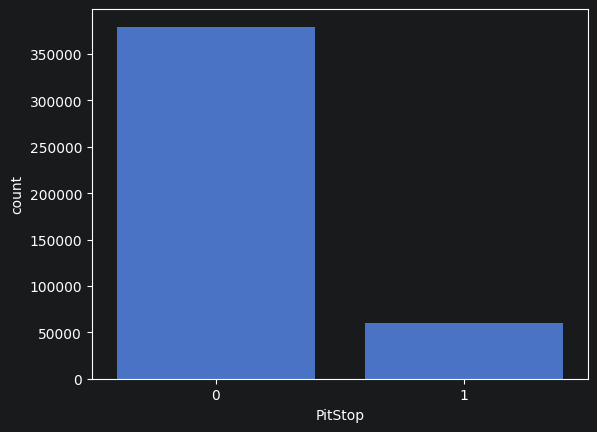

In [15]:
sns.countplot(data = train_df_deep, x = 'PitStop')

In [16]:
for i in train_df_deep.columns:
    print(f" {i} has unique value counts : {train_df_deep[i].nunique()}")

 Driver has unique value counts : 887
 Compound has unique value counts : 5
 Race has unique value counts : 26
 Year has unique value counts : 4
 PitStop has unique value counts : 2
 LapNumber has unique value counts : 78
 Stint has unique value counts : 8
 TyreLife has unique value counts : 78
 Position has unique value counts : 20
 LapTime (s) has unique value counts : 37719
 LapTime_Delta has unique value counts : 57532
 Cumulative_Degradation has unique value counts : 142701
 RaceProgress has unique value counts : 1898
 Position_Change has unique value counts : 37
 PitNextLap has unique value counts : 2


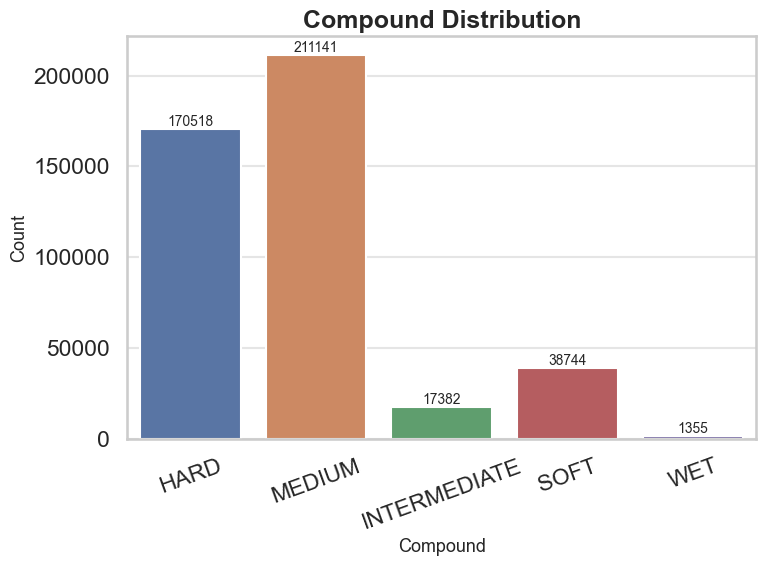

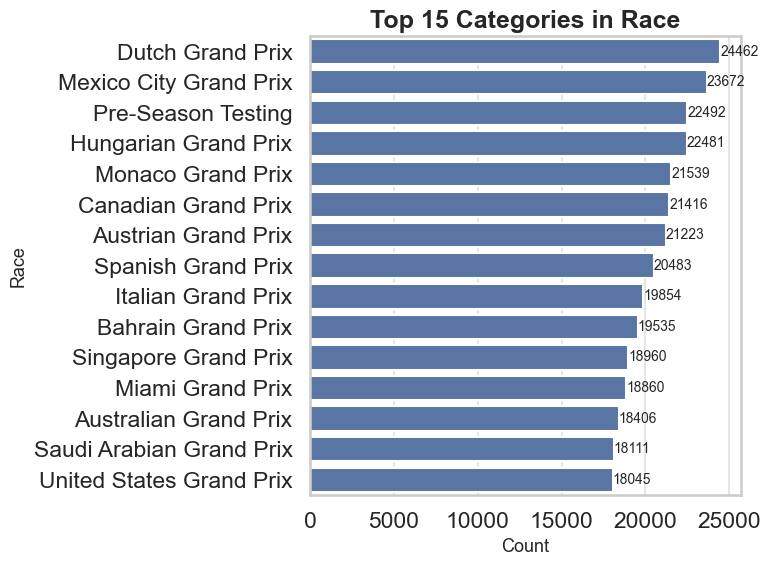

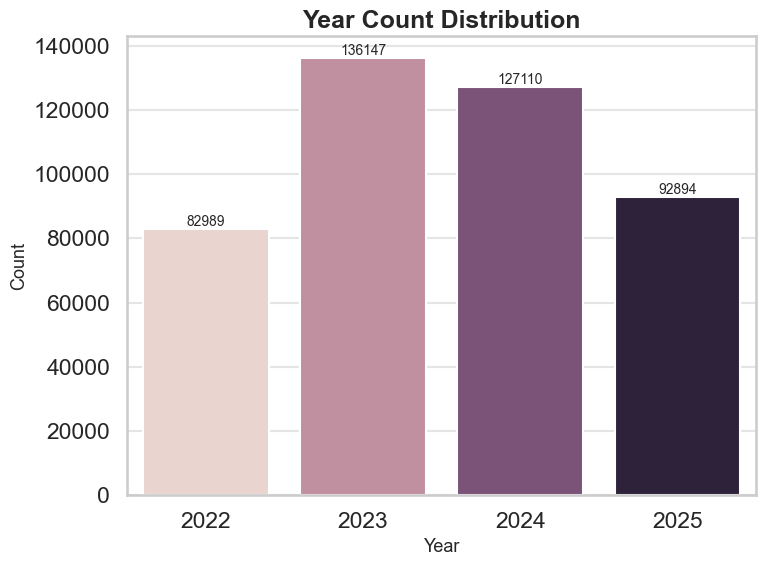

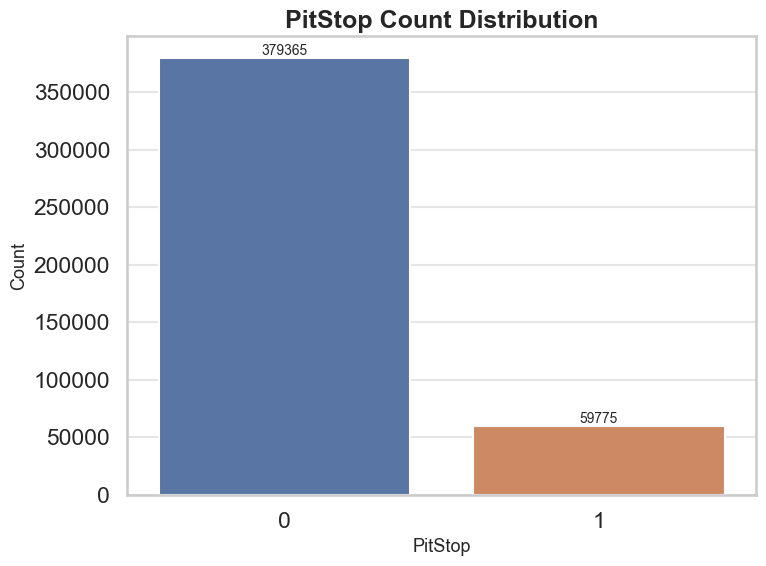

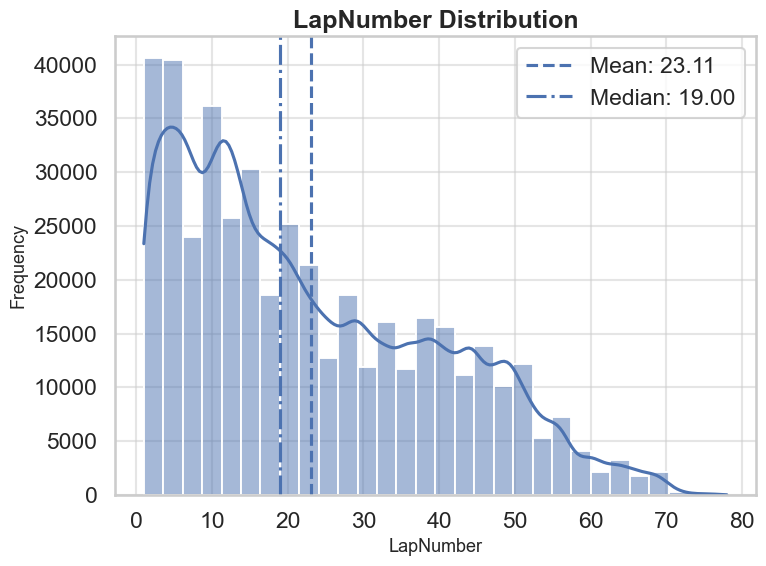

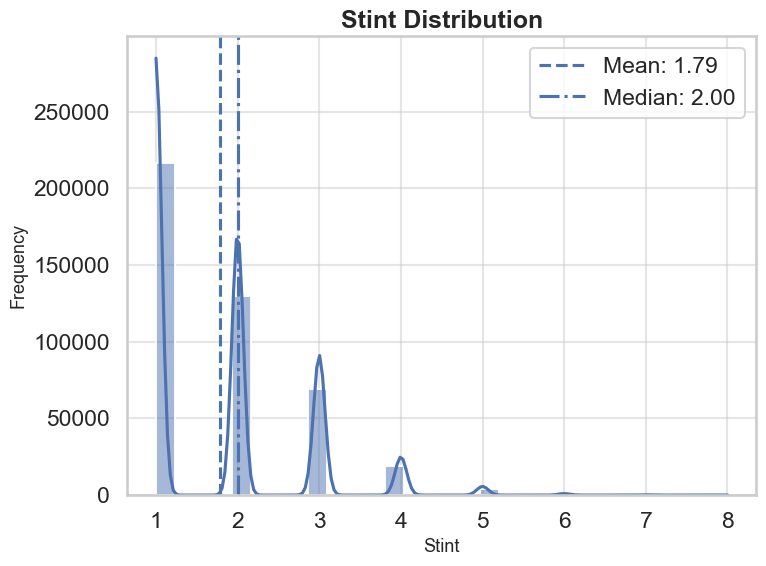

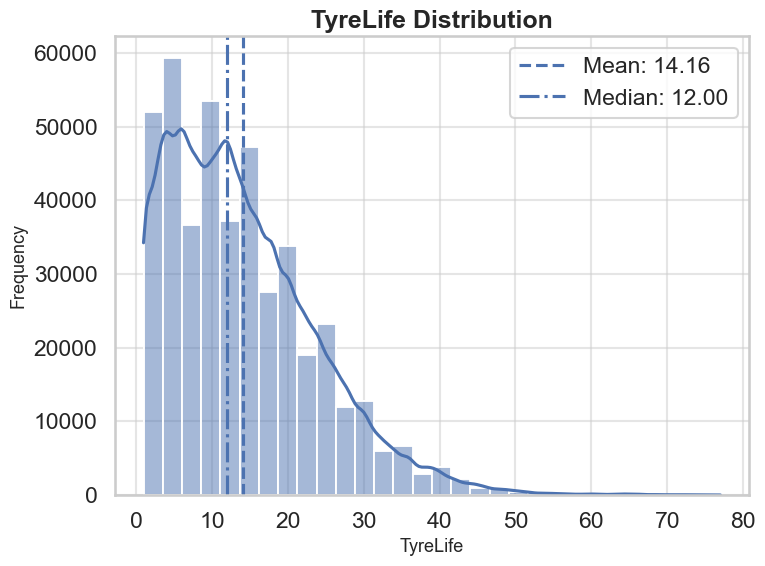

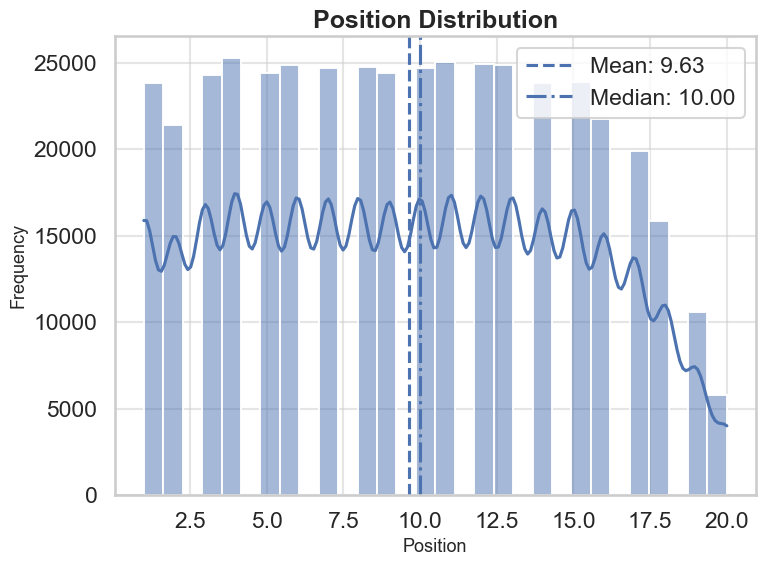

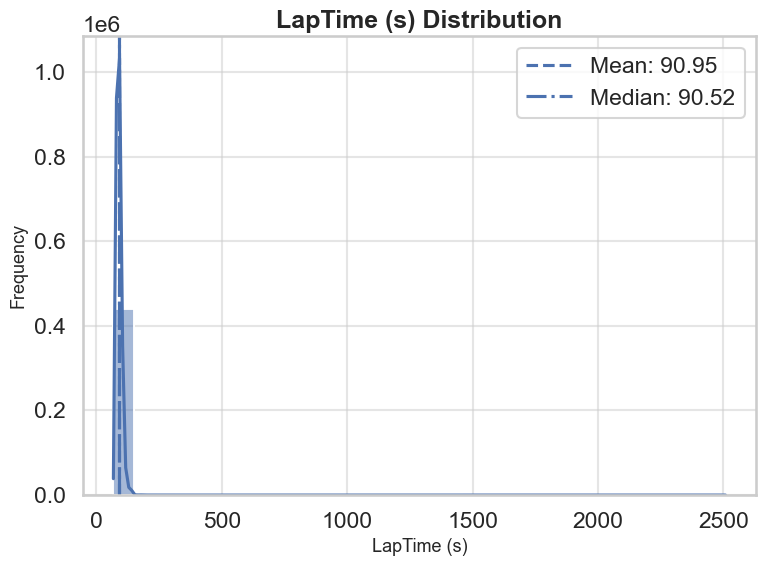

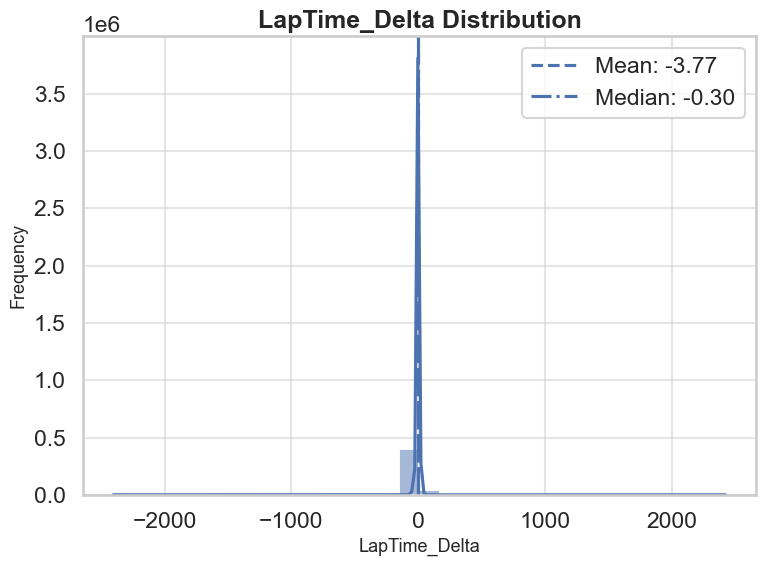

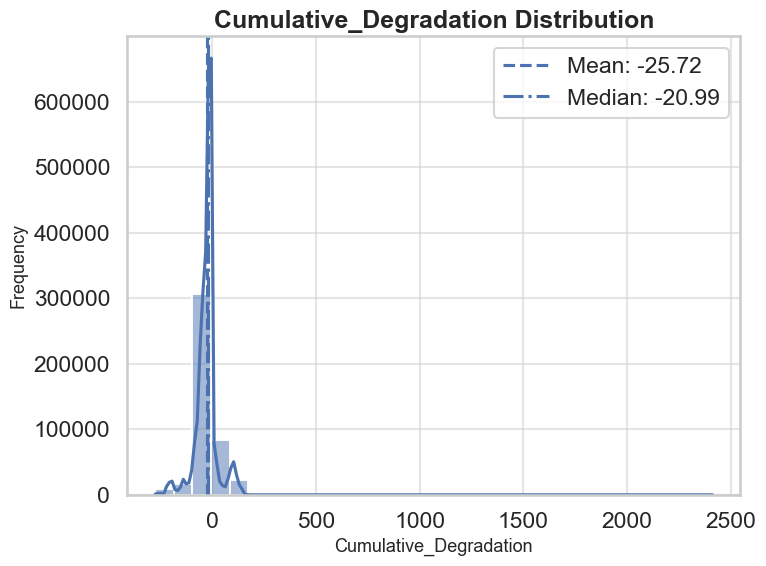

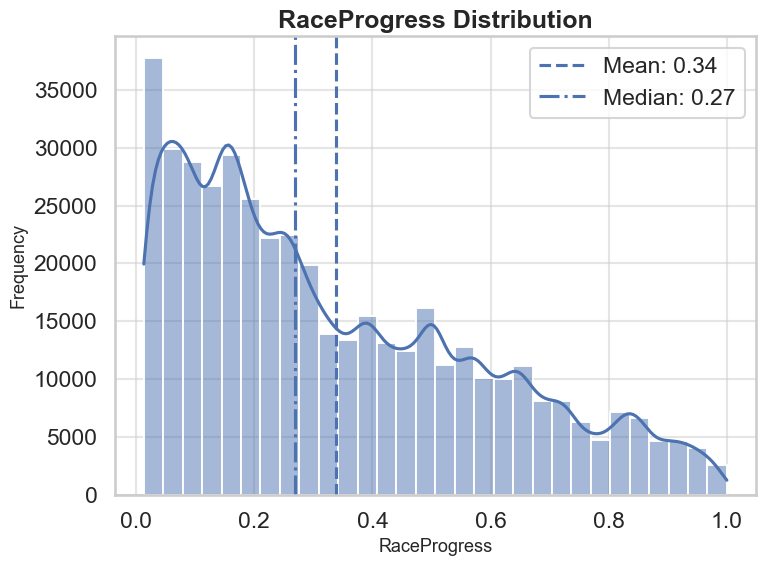

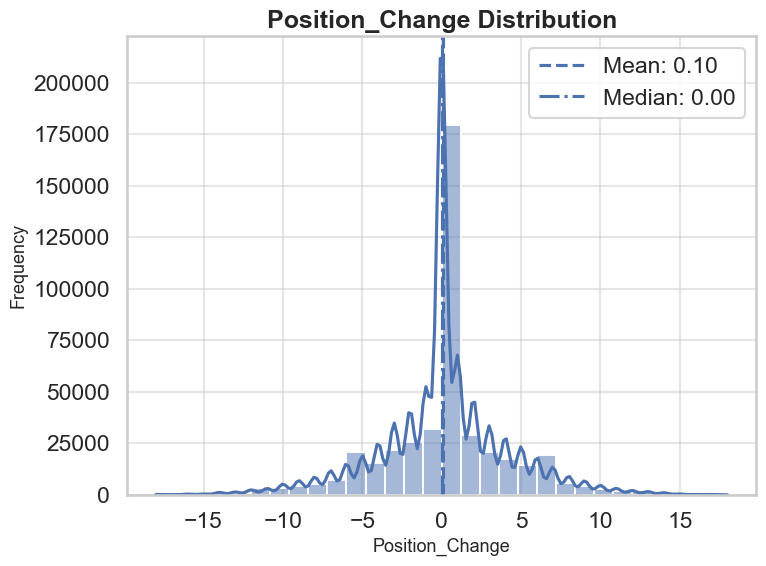

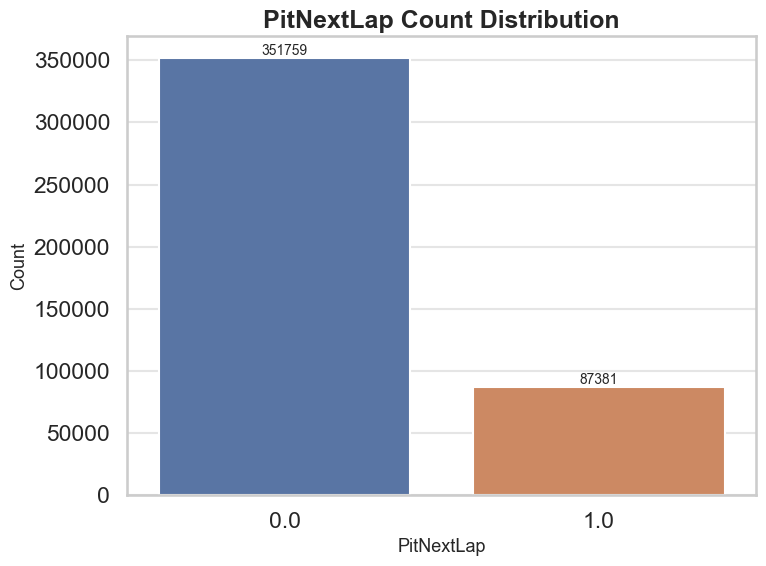

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set a clean plot style
sns.set_theme(style="whitegrid", context="talk")

# Default figure size
plt.rcParams["figure.figsize"] = (8, 6)

cols = [col for col in train_df_deep.columns if col != "Driver"]

for col in cols:

    plt.figure(figsize=(8, 6))

    if train_df_deep[col].dtype in ["object", "bool"]:

        nunique = train_df_deep[col].nunique()

        # Few unique values — use a count plot
        if nunique <= 10:

            ax = sns.countplot(
                data=train_df_deep,
                x=col,
                hue=col,
                legend=False
            )

            # Label each bar with its count
            for p in ax.patches:
                ax.annotate(
                    f"{int(p.get_height())}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center",
                    va="bottom",
                    fontsize=10
                )

            plt.title(f"{col} Distribution", fontsize=18, weight="bold")
            plt.xlabel(col, fontsize=13)
            plt.ylabel("Count", fontsize=13)
            plt.xticks(rotation=20)

        # Many unique values — show top 15
        else:

            vc = train_df_deep[col].value_counts().head(15)

            ax = sns.barplot(
                x=vc.values,
                y=vc.index
            )

            # Label each bar
            for p in ax.patches:
                ax.annotate(
                    f"{int(p.get_width())}",
                    (p.get_width(), p.get_y() + p.get_height()/2),
                    ha="left",
                    va="center",
                    fontsize=10
                )

            plt.title(f"Top 15 Categories in {col}", fontsize=18, weight="bold")
            plt.xlabel("Count", fontsize=13)
            plt.ylabel(col, fontsize=13)

    elif train_df_deep[col].dtype in ["int64", "float64"]:

        nunique = train_df_deep[col].nunique()

        # Discrete numbers — bar chart works better than hist
        if nunique <= 5:

            ax = sns.countplot(
                data=train_df_deep,
                x=col,
                hue=col,
                legend=False
            )

            for p in ax.patches:
                ax.annotate(
                    f"{int(p.get_height())}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center",
                    va="bottom",
                    fontsize=10
                )

            plt.title(f"{col} Count Distribution", fontsize=18, weight="bold")
            plt.xlabel(col, fontsize=13)
            plt.ylabel("Count", fontsize=13)

        # Continuous numbers — use a histogram
        else:

            ax = sns.histplot(
                data=train_df_deep,
                x=col,
                kde=True,
                bins=30
            )

            # Draw mean and median reference lines
            mean_val = train_df_deep[col].mean()
            median_val = train_df_deep[col].median()

            plt.axvline(mean_val, linestyle="--", label=f"Mean: {mean_val:.2f}")
            plt.axvline(median_val, linestyle="-.", label=f"Median: {median_val:.2f}")

            plt.legend()

            plt.title(f"{col} Distribution", fontsize=18, weight="bold")
            plt.xlabel(col, fontsize=13)
            plt.ylabel("Frequency", fontsize=13)

    plt.tight_layout()
    plt.show()

Check feature correlations


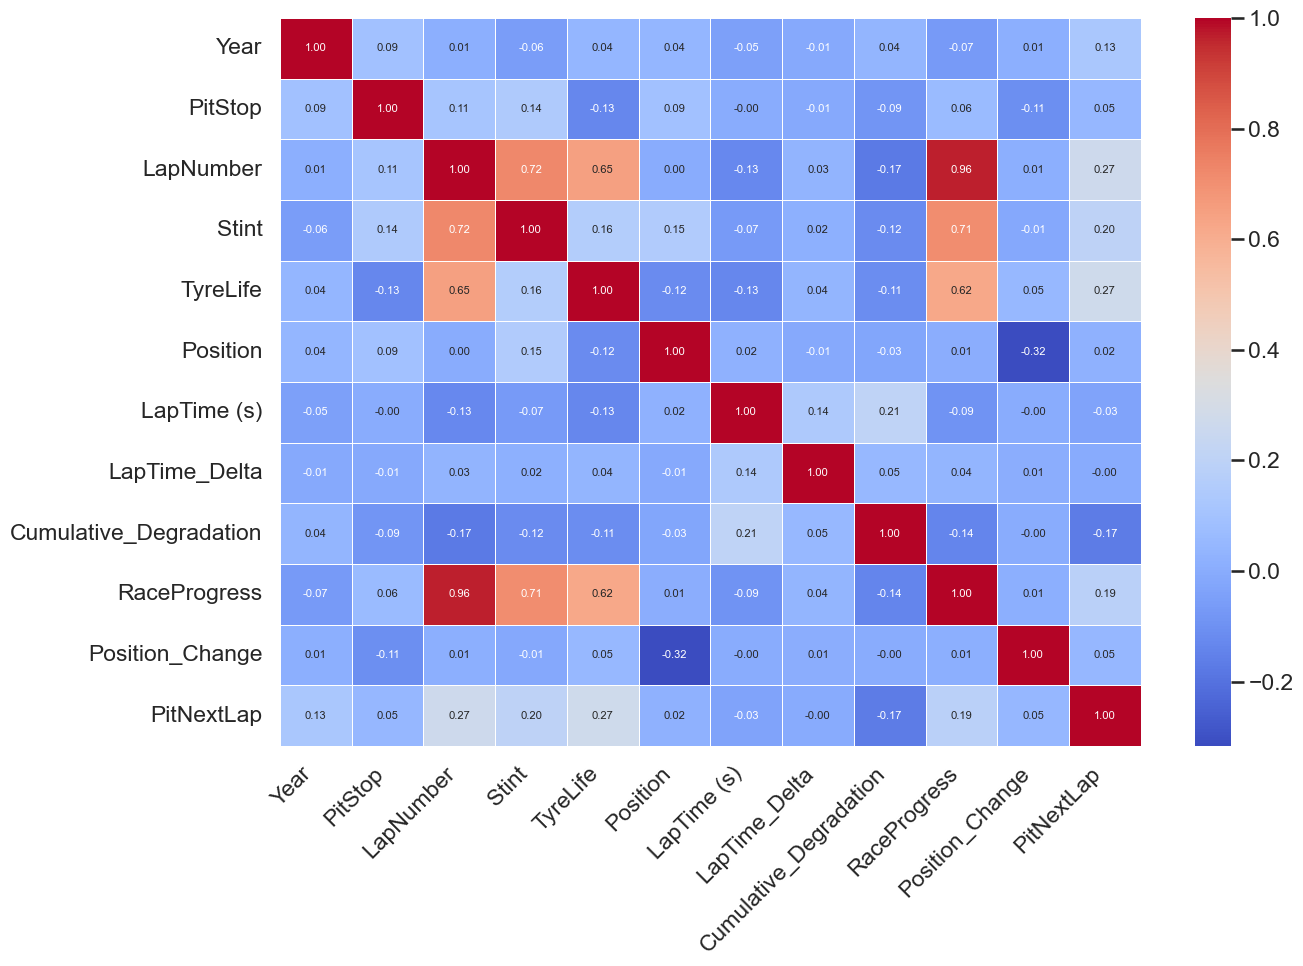

In [18]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    train_df_deep.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

In [19]:
from sklearn import set_config
set_config(transform_output = 'pandas')

Train/test split


In [20]:
total_train_records = train_df_deep.drop(columns=['PitNextLap']).copy()
total_train_labels = train_df_deep['PitNextLap'].copy()

# PitStop is kept in the feature matrix so that F1FeatureTransformer.fit()
# can compute pit-cluster counts (it groups by PitStop internally).
# It is dropped from X_train_eng / X_test_eng after feature engineering
# (see the fit_full cell below) so it never reaches the model.
# PitNextLap (the target) is 1 on the lap *before* a stop; PitStop is 1 on the
# lap *of* the stop. They are temporally adjacent and highly correlated.
# Keeping PitStop in the model would teach it a trivial shortcut rather than
# genuine tyre-degradation strategy, and it may not be reliably available at
# real prediction time (you don't know you're stopping until you stop).

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(total_train_records, total_train_labels, test_size= 0.1, shuffle= True, random_state=42, stratify = total_train_labels)

## Pipeline 1 — Feature engineering → Preprocessing → Feature selection

Fits once on the full `x_train`. No model step here.
The same fitted objects are reused to transform `x_test` — no refit, no leakage.

The dangerous statistics (`_race_mean_laptime`, `_compound_cliff`,
`_pit_cluster_map`, etc.) are all learned inside `fit()` which is called on
training data only. `transform()` applies those frozen statistics plus pure
row-arithmetic. Rolling/lag features use only raw lap-time values and do not
encode the target, so the negligible cross-fold-boundary contamination from
pre-computing `X_train_clean` once is not worth 750 extra feature-engineering
passes during Optuna tuning.


In [22]:
from f1_feature_transformer import F1FoldWiseWrapper
from f1_preprocessor import F1Preprocessor
from consensus_feature_selector import ConsensusFeatureSelector
import lightgbm as lgb
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [23]:
# Step 1a: Feature engineering — fit on x_train, transform both splits.
# Row re-alignment:
#   F1FeatureTransformer.transform() sorts rows by [Race,Year,Driver,LapNumber]
#   and resets the index. y_train/y_test from train_test_split still carry the
#   original non-contiguous index. We apply the same sort key to x_train/x_test,
#   use those sorted indices to re-align y, then reset everything to 0..N-1.

_GROUP_SORT = ['Race', 'Year', 'Driver', 'LapNumber']

_x_train_sort_idx = x_train.sort_values(_GROUP_SORT).index
_x_test_sort_idx  = x_test.sort_values(_GROUP_SORT).index

y_train = y_train.loc[_x_train_sort_idx].reset_index(drop=True)
y_test  = y_test.loc[_x_test_sort_idx].reset_index(drop=True)

x_train = x_train.loc[_x_train_sort_idx].reset_index(drop=True)
x_test  = x_test.loc[_x_test_sort_idx].reset_index(drop=True)

feat_wrapper = F1FoldWiseWrapper(
    n_splits=5, random_state=42, lag_windows=[1, 3, 5], verbose=True
)
feat_wrapper.fit_full(x_train, y_train)
X_train_eng = feat_wrapper._full_transformer.transform(x_train)
X_test_eng  = feat_wrapper.transform_test(x_test)

# Drop PitStop from engineered features — it was needed by the transformer
# for pit-cluster statistics but must not be seen by the model (data leakage).
X_train_eng = X_train_eng.drop(columns=['PitStop'], errors='ignore')
X_test_eng  = X_test_eng.drop(columns=['PitStop'], errors='ignore')

assert len(X_train_eng) == len(y_train), "Row count mismatch after alignment"
assert len(X_test_eng)  == len(y_test),  "Row count mismatch after alignment"
assert list(X_train_eng.index) == list(y_train.index), "Index mismatch"
assert list(X_test_eng.index)  == list(y_test.index),  "Index mismatch"
print(f'After feature engineering — train: {X_train_eng.shape}, test: {X_test_eng.shape}')
print('Row alignment confirmed.')


── Full-data fit (test inference transformer) ───────────────────────────


  rolling windows: 100%|██████████| 3/3 [01:54<00:00, 36.96s/it]



── Transforming test set ───────────────────────────────────────────────


  rolling windows: 100%|██████████| 3/3 [01:01<00:00, 20.42s/it]


After feature engineering — train: (395226, 78), test: (43914, 78)
Row alignment confirmed.


In [24]:
# Step 1b: Preprocessing — fit on X_train_eng, transform both splits.
preprocessor = F1Preprocessor(passthrough_binary=True, winsor_q=(0.001, 0.999))
X_train_pp = preprocessor.fit_transform(X_train_eng)
X_test_pp  = preprocessor.transform(X_test_eng)
print(f'After preprocessing — train: {X_train_pp.shape}, test: {X_test_pp.shape}')

After preprocessing — train: (395226, 78), test: (43914, 78)


In [25]:
# Step 1c: Feature selection — fit on X_train_pp, transform both splits.
# Caching: if feature_selection_cache.json exists in the working directory,
# the selector result is loaded directly without re-running the expensive fit.
# Delete the JSON to force a fresh run (e.g. after changing hyperparams or
# upstream feature engineering).

import json
import os
import pandas as pd

_CACHE_PATH = os.path.join(os.getcwd(), "feature_selection_cache.json")

_SELECTOR_PARAMS = dict(
    top_n_start             = 40,
    batch_size              = 5,
    min_auc_gain            = 0.0005,
    stability_std_threshold = 0.005,
    n_inner_splits          = 3,
    perm_n_repeats          = 10,
    shap_sample             = 5000,
    random_state            = 42,
    verbose                 = True,
)

if os.path.exists(_CACHE_PATH):
    # ── CACHE HIT: load features from JSON ───────────────────────────────────
    print(f"[FeatureSelection] Cache found — loading from '{_CACHE_PATH}'.")
    with open(_CACHE_PATH, "r") as f:
        _cache = json.load(f)

    # Sanity-check: warn if stored hyperparams differ from current config
    _meta       = _cache.get("meta", {})
    _check_keys = ["top_n_start", "batch_size", "min_auc_gain",
                   "stability_std_threshold", "n_inner_splits",
                   "perm_n_repeats", "shap_sample", "random_state"]
    _mismatches = [k for k in _check_keys
                   if _meta.get(k) is not None and _meta[k] != _SELECTOR_PARAMS[k]]
    if _mismatches:
        print(f"[FeatureSelection] WARNING: cached params differ for: {_mismatches}. "
              f"Delete '{_CACHE_PATH}' and re-run to regenerate with current settings.")

    class _CachedSelector:
        """Drop-in replacement for a fitted ConsensusFeatureSelector when
            loading from cache. Exposes the same attributes and methods that the
            rest of the pipeline uses."""

        def __init__(self, features, cache):
            self.selected_features_ = features
            self.selection_log_     = pd.DataFrame(cache.get("selection_log", []))
            self.removed_constant_  = cache.get("meta", {}).get("constant_columns_removed", [])
            # Not serialised — available only on a live run
            self.consensus_ranking_ = pd.Series(dtype=float)
            self.importance_table_  = pd.DataFrame()

        def transform(self, X: pd.DataFrame) -> pd.DataFrame:
            present = [c for c in self.selected_features_ if c in X.columns]
            missing = [c for c in self.selected_features_ if c not in X.columns]
            if missing:
                print(f"[CachedSelector] WARNING: {len(missing)} feature(s) in cache "
                      f"not found in X — skipping: {missing}")
            return X[present].copy()

        def selection_report(self) -> str:
            lines = [
                "=" * 68,
                "ConsensusFeatureSelector — CACHED Selection Report",
                "=" * 68,
                f"Loaded from             : {_CACHE_PATH}",
                f"Constant columns removed: {self.removed_constant_}",
                "",
                f"Final selected features : {len(self.selected_features_)}",
                "  " + ", ".join(self.selected_features_),
                "",
                "NOTE: consensus_ranking_ and importance_table_ are not available",
                "      from cache. Delete the cache file to recompute them.",
                "=" * 68,
            ]
            return "\n".join(lines)

    selector = _CachedSelector(_cache["selected_features"], _cache)
    print(f"[FeatureSelection] {len(selector.selected_features_)} features loaded from cache.")

else:
    # ── CACHE MISS: run selector and save results ─────────────────────────────
    print(f"[FeatureSelection] No cache found — running ConsensusFeatureSelector.")

    selector = ConsensusFeatureSelector(
        estimator=lgb.LGBMClassifier(
            n_estimators      = 300,
            learning_rate     = 0.05,
            num_leaves        = 63,
            min_child_samples = 20,
            random_state      = 42,
            verbose           = -1,
            device            = LGB_DEVICE,
        ),
        **_SELECTOR_PARAMS,
    )
    selector.fit(X_train_pp, y_train)

    # Persist to JSON so future runs skip this step
    _cache_data = {
        "meta": {
            "generated_by":             "ConsensusFeatureSelector",
            "competition":              "playground-series-s6e5",
            **{k: v for k, v in _SELECTOR_PARAMS.items() if k != "verbose"},
            "lgb_device":               LGB_DEVICE,
            "n_features_selected":      len(selector.selected_features_),
            "n_features_input":         X_train_pp.shape[1],
            "constant_columns_removed": selector.removed_constant_,
            "note": (
                "Cache is tied to: random_state=42, test_size=0.1, "
                "F1FoldWiseWrapper + F1Preprocessor, and _SELECTOR_PARAMS above. "
                "Delete this file if any of those change."
            ),
        },
        "selected_features": selector.selected_features_,
        "selection_log":     selector.selection_log_.to_dict(orient="records"),
    }
    with open(_CACHE_PATH, "w") as f:
        json.dump(_cache_data, f, indent=2)
    print(f"[FeatureSelection] Cache saved to '{_CACHE_PATH}'.")

# ── Apply selection (same regardless of cache hit/miss) ───────────────────────
X_train_clean = selector.transform(X_train_pp)
X_test_clean  = selector.transform(X_test_pp)

print(selector.selection_report())
print(f'After feature selection — train: {X_train_clean.shape}, test: {X_test_clean.shape}')
print('Pipeline 1 complete. X_test_clean is now LOCKED.')

[FeatureSelection] Cache found — loading from 'C:\Users\ASUS\Desktop\Courses\ML DL\Machine Learning\Projects\Classification\F1 Pitstop Prediction\feature_selection_cache.json'.
[FeatureSelection] 40 features loaded from cache.
ConsensusFeatureSelector — CACHED Selection Report
Loaded from             : C:\Users\ASUS\Desktop\Courses\ML DL\Machine Learning\Projects\Classification\F1 Pitstop Prediction\feature_selection_cache.json
Constant columns removed: ['roll_lt_mean_3']

Final selected features : 40
  RaceProgress, race_enc, Year, laptime_delta_abs, Stint, Cumulative_Degradation, total_race_laps, LapTime (s), LapNumber, LapTime_Delta, laptime_zscore, is_cluster_lap, tyre_life_norm, driver_enc, Position_Change, laps_remaining, Position, tyre_life_sq, position_change_abs, deg_per_lap, roll_delta_5, laps_remaining_norm, tyreage_x_progress, position_trend, deg_accel, urgency_index, roll_deg_3, TyreLife, roll_lt_mean_5, position_norm, tyre_life_log, roll_delta_1, roll_deg_5, is_first_stin

## Pipeline 1 (full) — Refit transforms on 100% of labeled data

Feature engineering, preprocessing, and the test transform are refit on
`total_train_records` so the final base models see all labeled rows.
Feature selection is **not** rerun — the same selected features from the
90% split are reused via `selector.transform()` to avoid expensive
re-selection and keep OOF calibration consistent.


In [41]:
# ── Refit Pipeline 1 on 100% of labeled data ──────────────────────────────────
# Optuna hyperparams are already found above — we only refit the transforms
# and will refit the base models on this larger dataset after cell 41.

_GROUP_SORT = ['Race', 'Year', 'Driver', 'LapNumber']

# Sort full dataset the same way feat_wrapper sorts internally
_full_sort_idx      = total_train_records.sort_values(_GROUP_SORT).index
total_train_sorted  = total_train_records.loc[_full_sort_idx].reset_index(drop=True)
total_labels_sorted = total_train_labels.loc[_full_sort_idx].reset_index(drop=True)

# Step 1: Feature engineering on full data
feat_wrapper_full = F1FoldWiseWrapper(
    n_splits=5, random_state=42, lag_windows=[1, 3, 5], verbose=False
)
feat_wrapper_full.fit_full(total_train_sorted, total_labels_sorted)
X_full_eng = feat_wrapper_full._full_transformer.transform(total_train_sorted)
X_full_eng = X_full_eng.drop(columns=['PitStop'], errors='ignore')

# Step 2: Preprocessing on full data
preprocessor_full = F1Preprocessor(passthrough_binary=True, winsor_q=(0.001, 0.999))
X_full_pp = preprocessor_full.fit_transform(X_full_eng)

# Step 3: Apply existing selector (no refit — reuse 90%-split selected features)
X_full_clean = selector.transform(X_full_pp)
y_full       = total_labels_sorted

print(f'Full training set — shape: {X_full_clean.shape}, labels: {y_full.shape}')
print('Pipeline 1 (full) complete.')



── Full-data fit (test inference transformer) ───────────────────────────
Full training set — shape: (439140, 40), labels: (439140,)
Pipeline 1 (full) complete.


## Optuna — Hyperparameter tuning (model params only)

`X_train_clean` is passed in directly. Pipeline 1 is not re-run here.
Each trial creates a temporary model for CV scoring and throws it away after.
One study per base model.



In [26]:
CV_FOLDS    = 5
N_TRIALS    = 50
RANDOM_SEED = 42

skf_optuna = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
skf_oof    = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED + 1)

import gc
import torch
import concurrent.futures
from tqdm.auto import tqdm as tqdm_auto

def _cuda_cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()

class TqdmOptunaCallback:
    def __init__(self, n_trials, desc="Optuna"):
        self._bar = tqdm_auto(total=n_trials, desc=desc, unit="trial")

    def __call__(self, study, trial):
        try:
            self._bar.set_postfix({"best": f"{study.best_value:.5f}"}, refresh=False)
        except ValueError:
            pass
        self._bar.update(1)

    def close(self):
        self._bar.close()

TRIAL_TIMEOUT_LGB      = 90
TRIAL_TIMEOUT_XGB      = 90
TRIAL_TIMEOUT_LGB_DART = 120

def _run_with_timeout(fn, timeout_seconds):
    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as ex:
        future = ex.submit(fn)
        try:
            return future.result(timeout=timeout_seconds)
        except concurrent.futures.TimeoutError:
            raise optuna.TrialPruned(f"Trial exceeded {timeout_seconds}s — pruned.")

def objective_lgb(trial):
    model = lgb.LGBMClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 150),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 100),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        random_state=RANDOM_SEED, verbose=-1, device=LGB_DEVICE,
    )
    def _cv():
        return cross_val_score(
            model, X_train_clean, y_train,
            cv=skf_optuna, scoring='roc_auc', n_jobs=1,
        ).mean()
    return _run_with_timeout(_cv, TRIAL_TIMEOUT_LGB)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 20),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        use_label_encoder=False, eval_metric='logloss',
        random_state=RANDOM_SEED, verbosity=0, device=XGB_DEVICE,
    )
    def _cv():
        return cross_val_score(
            model, X_train_clean, y_train,
            cv=skf_optuna, scoring='roc_auc', n_jobs=1,
        ).mean()
    return _run_with_timeout(_cv, TRIAL_TIMEOUT_XGB)

def objective_lgb_dart(trial):
    model = lgb.LGBMClassifier(
        boosting_type     = 'dart',
        n_estimators      = trial.suggest_int('n_estimators', 100, 300),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 120),
        drop_rate         = trial.suggest_float('drop_rate', 0.05, 0.5),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 80),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        random_state=RANDOM_SEED, verbose=-1, device=LGB_DEVICE,
    )
    def _cv():
        return cross_val_score(
            model, X_train_clean, y_train,
            cv=skf_optuna, scoring='roc_auc', n_jobs=1,
        ).mean()
    return _run_with_timeout(_cv, TRIAL_TIMEOUT_LGB_DART)

In [27]:
import json
import os

# Separate JSON file per model — granular caching.
# Each study checks its own file first; only missing/corrupt ones are re-tuned.
PARAMS_DIR           = "."          # change to a subfolder if preferred
PARAMS_FILE_LGB      = os.path.join(PARAMS_DIR, "optuna_params_lgb.json")
PARAMS_FILE_XGB      = os.path.join(PARAMS_DIR, "optuna_params_xgb.json")
PARAMS_FILE_LGB_DART = os.path.join(PARAMS_DIR, "optuna_params_lgb_dart.json")

def _load_params(filepath: str, model_name: str) -> dict | None:
    """
        Load params from a JSON file.  Returns the dict on success, None if the
        file is missing, empty, corrupt, or doesn't contain a non-empty dict.
        """
    if not os.path.isfile(filepath):
        return None
    try:
        with open(filepath, "r") as f:
            data = json.load(f)
        if isinstance(data, dict) and len(data) > 0:
            print(f"  [{model_name}] Loaded cached params from {filepath}")
            return data
        print(f"  [{model_name}] Cache file exists but is empty/invalid — will re-tune.")
    except (json.JSONDecodeError, OSError) as exc:
        print(f"  [{model_name}] Cache file corrupt ({exc}) — will re-tune.")
    return None

def _save_params(filepath: str, params: dict, model_name: str) -> None:
    """Atomically write params to JSON (write to .tmp then rename)."""
        tmp = filepath + ".tmp"
        with open(tmp, "w") as f:
            json.dump(params, f, indent=4)
        os.replace(tmp, filepath)
        print(f"  [{model_name}] Saved best params → {filepath}")
    def _run_study(objective, n_trials: int, seed: int, desc: str):
        """Create an Optuna study, run it with a tqdm progress bar, return best params."""
    cb = TqdmOptunaCallback(n_trials=n_trials, desc=desc)
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    try:
        # show_progress_bar=False — we use TqdmOptunaCallback instead,
        # which renders correctly inside Jupyter notebook cells.
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False, callbacks=[cb])
    finally:
        cb.close()
    return study.best_params, study.best_value

# ── LightGBM (gbdt) ────────────────────────────────────────────────────────────
print("── LightGBM (gbdt) ──────────────────────────────────────────")
best_params_lgb = _load_params(PARAMS_FILE_LGB, "LGB-gbdt")
if best_params_lgb is None:
    best_params_lgb, lgb_best_auc = _run_study(
        objective_lgb, N_TRIALS, RANDOM_SEED, "LGB-gbdt"
    )
    print(f"  LGB best AUC: {lgb_best_auc:.5f}  params: {best_params_lgb}")
    _save_params(PARAMS_FILE_LGB, best_params_lgb, "LGB-gbdt")
    _cuda_cleanup()

# ── XGBoost ────────────────────────────────────────────────────────────────────
print("\n── XGBoost ──────────────────────────────────────────────────")
best_params_xgb = _load_params(PARAMS_FILE_XGB, "XGB")
if best_params_xgb is None:
    best_params_xgb, xgb_best_auc = _run_study(
        objective_xgb, N_TRIALS, RANDOM_SEED, "XGBoost"
    )
    print(f"  XGB best AUC: {xgb_best_auc:.5f}  params: {best_params_xgb}")
    _save_params(PARAMS_FILE_XGB, best_params_xgb, "XGB")
    _cuda_cleanup()

# ── LightGBM (dart) ────────────────────────────────────────────────────────────
print("\n── LightGBM (dart) ──────────────────────────────────────────")
best_params_lgb_dart = _load_params(PARAMS_FILE_LGB_DART, "LGB-dart")
if best_params_lgb_dart is None:
    best_params_lgb_dart, dart_best_auc = _run_study(
        objective_lgb_dart, N_TRIALS, RANDOM_SEED, "LGB-dart"
    )
    print(f"  LGB-DART best AUC: {dart_best_auc:.5f}  params: {best_params_lgb_dart}")
    _save_params(PARAMS_FILE_LGB_DART, best_params_lgb_dart, "LGB-dart")
    _cuda_cleanup()

print("\nOptuna done. best_params_lgb / best_params_xgb / best_params_lgb_dart are ready.")


── LightGBM (gbdt) ──────────────────────────────────────────
  [LGB-gbdt] Loaded cached params from .\optuna_params_lgb.json

── XGBoost ──────────────────────────────────────────────────
  [XGB] Loaded cached params from .\optuna_params_xgb.json

── LightGBM (dart) ──────────────────────────────────────────
  [LGB-dart] Loaded cached params from .\optuna_params_lgb_dart.json

Optuna done. best_params_lgb / best_params_xgb / best_params_lgb_dart are ready.


## Base models — final instantiation with best_params
These are the real model objects, not the throwaway ones from Optuna trials.
They get fit on the full `X_train_clean` and are kept for the ensemble.


In [42]:
# Create the final model objects using the best params from Optuna
base_lgb = lgb.LGBMClassifier(
    **best_params_lgb,
    random_state=RANDOM_SEED,
    verbose=-1,
    device=LGB_DEVICE,
)

base_xgb = XGBClassifier(
    **best_params_xgb,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
    verbosity=0,
    device=XGB_DEVICE,
)

base_lgb_dart = lgb.LGBMClassifier(
    **best_params_lgb_dart,
    boosting_type='dart',
    random_state=RANDOM_SEED,
    verbose=-1,
    device=LGB_DEVICE,
)

# Fit on x_train split — used for OOF generation and calibration below
print('Fitting base models on X_train_clean (90% split)...')
base_lgb.fit(X_train_clean, y_train)
print('  LGB (gbdt)  — done')
base_xgb.fit(X_train_clean, y_train)
print('  XGB         — done')
base_lgb_dart.fit(X_train_clean, y_train)
print('  LGB (dart)  — done')
print('Base models fitted on 90% split. OOF + calibration will use these.')

# Refit on full labeled data — these are the objects used for final submission
print('\nRefitting base models on FULL dataset (100%)...')
base_lgb.fit(X_full_clean, y_full)
print('  LGB (gbdt)  — done')
base_xgb.fit(X_full_clean, y_full)
print('  XGB         — done')
base_lgb_dart.fit(X_full_clean, y_full)
print('  LGB (dart)  — done')
print('Base models refit on 100% of labeled data. Ready for submission.')


Fitting base models on X_train_clean (90% split)...
  LGB (gbdt)  — done
  XGB         — done
  LGB (dart)  — done
Base models fitted on 90% split. OOF + calibration will use these.

Refitting base models on FULL dataset (100%)...
  LGB (gbdt)  — done
  XGB         — done
  LGB (dart)  — done
Base models refit on 100% of labeled data. Ready for submission.


## Out-of-fold (OOF) predictions on `X_train_clean`

Used to train the meta-learner for stacking/blending.
`X_train_clean` is split fold-wise using `skf_oof` (different seed from Optuna).
Only the model runs per fold — no preprocessing is repeated.


In [29]:
# Generate out-of-fold RAW MARGINS from each base model.
# Uses skf_oof (seed=43) — different splits from Optuna (seed=42).

from sklearn.base import clone
from tqdm import tqdm

n_train = len(X_train_clean)
oof_lgb_margin      = np.zeros(n_train)
oof_xgb_margin      = np.zeros(n_train)
oof_lgb_dart_margin = np.zeros(n_train)
oof_lgb_proba       = np.zeros(n_train)
oof_xgb_proba       = np.zeros(n_train)
oof_lgb_dart_proba  = np.zeros(n_train)

folds = list(skf_oof.split(X_train_clean, y_train))

for fold, (tr_idx, val_idx) in enumerate(tqdm(folds, desc='OOF folds')):
    X_tr  = X_train_clean.iloc[tr_idx]
    X_val = X_train_clean.iloc[val_idx]
    y_tr  = y_train.iloc[tr_idx]

    m_lgb  = clone(base_lgb);      m_lgb.fit(X_tr, y_tr)
    m_xgb  = clone(base_xgb);      m_xgb.fit(X_tr, y_tr)
    m_dart = clone(base_lgb_dart); m_dart.fit(X_tr, y_tr)

    oof_lgb_margin[val_idx]      = m_lgb.predict(X_val, raw_score=True)
    oof_xgb_margin[val_idx]      = m_xgb.predict(X_val.values, output_margin=True)
    oof_lgb_dart_margin[val_idx] = m_dart.predict(X_val, raw_score=True)

    oof_lgb_proba[val_idx]      = m_lgb.predict_proba(X_val)[:, 1]
    oof_xgb_proba[val_idx]      = m_xgb.predict_proba(X_val)[:, 1]
    oof_lgb_dart_proba[val_idx] = m_dart.predict_proba(X_val)[:, 1]

print(f'OOF AUC (proba) — LGB:      {roc_auc_score(y_train, oof_lgb_proba):.5f}')
print(f'OOF AUC (proba) — XGB:      {roc_auc_score(y_train, oof_xgb_proba):.5f}')
print(f'OOF AUC (proba) — LGB-DART: {roc_auc_score(y_train, oof_lgb_dart_proba):.5f}')
print()
print(f'OOF AUC (margin) — LGB:      {roc_auc_score(y_train, oof_lgb_margin):.5f}')
print(f'OOF AUC (margin) — XGB:      {roc_auc_score(y_train, oof_xgb_margin):.5f}')
print(f'OOF AUC (margin) — LGB-DART: {roc_auc_score(y_train, oof_lgb_dart_margin):.5f}')

meta_train = pd.DataFrame({
    'lgb_margin':      oof_lgb_margin,
    'xgb_margin':      oof_xgb_margin,
    'lgb_dart_margin': oof_lgb_dart_margin,
})
print(f'\nmeta_train shape: {meta_train.shape}')

OOF folds: 100%|██████████| 5/5 [04:25<00:00, 53.09s/it]


OOF AUC (proba) — LGB:      0.94657
OOF AUC (proba) — XGB:      0.94666
OOF AUC (proba) — LGB-DART: 0.94354

OOF AUC (margin) — LGB:      0.94657
OOF AUC (margin) — XGB:      0.94666
OOF AUC (margin) — LGB-DART: 0.94354

meta_train shape: (395226, 3)


## Probability calibration — per base model, fit on OOF margins

**Fix:** a 5-fold inner KFold on the OOF margins compares both calibrators on
*held-out* Brier scores. The winner is then re-fit on the full OOF data to
produce the final calibration objects used at inference time.


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import KFold
from scipy.special import expit
import warnings

def fit_best_calibrator(oof_margins, y_true, model_name,
                        n_inner_splits=5, random_state=42):
    """
        from an inner KFold on the OOF margins — not in-sample scores.
        Steps:
          1. KFold CV on (oof_margins, y_true): for each inner fold fit both
             calibrators on inner-tr, score Brier on inner-val.
          2. Pick the calibrator with lower mean held-out Brier.
          3. Re-fit the winner on the full OOF data.
        """
    y = y_true.values if hasattr(y_true, 'values') else y_true
    m = oof_margins

    kf = KFold(n_splits=n_inner_splits, shuffle=True, random_state=random_state)

    platt_briers, iso_briers = [], []

    for tr_idx, val_idx in kf.split(m):
        m_tr, m_val = m[tr_idx].reshape(-1, 1), m[val_idx].reshape(-1, 1)
        y_tr, y_val = y[tr_idx], y[val_idx]

        platt_cv = LogisticRegression(C=1.0, max_iter=1000)
        platt_cv.fit(m_tr, y_tr)
        platt_briers.append(brier_score_loss(y_val, platt_cv.predict_proba(m_val)[:, 1]))

        iso_cv = IsotonicRegression(out_of_bounds='clip')
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            iso_cv.fit(m[tr_idx], y_tr)
        iso_briers.append(brier_score_loss(y_val, iso_cv.predict(m[val_idx])))

    mean_platt = float(np.mean(platt_briers))
    mean_iso   = float(np.mean(iso_briers))
    raw_brier  = brier_score_loss(y, expit(m))

    print(f'  {model_name}:')
    print(f'    Uncalibrated sigmoid          Brier: {raw_brier:.5f}')
    print(f'    Platt (held-out CV mean)      Brier: {mean_platt:.5f}')
    print(f'    Isotonic (held-out CV mean)   Brier: {mean_iso:.5f}')

    winner_name = 'platt' if mean_platt <= mean_iso else 'isotonic'
    delta = abs(mean_platt - mean_iso)
    print(f'    -> {winner_name.capitalize()} chosen  (delta={delta:.5f})')

    # Re-fit winner on full OOF data
    if winner_name == 'platt':
        winner = LogisticRegression(C=1.0, max_iter=1000)
        winner.fit(m.reshape(-1, 1), y)
        final_proba = winner.predict_proba(m.reshape(-1, 1))[:, 1]
    else:
        winner = IsotonicRegression(out_of_bounds='clip')
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            winner.fit(m, y)
        final_proba = winner.predict(m)

    return winner, winner_name, final_proba

print('Fitting calibrators on OOF margins (inner-CV selection)...')
print()

cal_lgb,  cal_lgb_name,  oof_lgb_cal  = fit_best_calibrator(oof_lgb_margin,      y_train, 'LGB (gbdt)')
cal_xgb,  cal_xgb_name,  oof_xgb_cal  = fit_best_calibrator(oof_xgb_margin,      y_train, 'XGB')
cal_dart, cal_dart_name, oof_dart_cal  = fit_best_calibrator(oof_lgb_dart_margin, y_train, 'LGB (dart)')

print()
print(f'Calibrated OOF AUC — LGB:      {roc_auc_score(y_train, oof_lgb_cal):.5f}')
print(f'Calibrated OOF AUC — XGB:      {roc_auc_score(y_train, oof_xgb_cal):.5f}')
print(f'Calibrated OOF AUC — LGB-DART: {roc_auc_score(y_train, oof_dart_cal):.5f}')

meta_train_cal = pd.DataFrame({
    'lgb_cal':  oof_lgb_cal,
    'xgb_cal':  oof_xgb_cal,
    'dart_cal': oof_dart_cal,
})
print(f'\nmeta_train_cal shape: {meta_train_cal.shape}')

def apply_calibrator(calibrator, method_name, test_margins):
    if method_name == 'platt':
        return calibrator.predict_proba(test_margins.reshape(-1, 1))[:, 1]
    else:
        return calibrator.predict(test_margins)

Fitting calibrators on OOF margins (inner-CV selection)...

  LGB (gbdt):
    Uncalibrated sigmoid          Brier: 0.07239
    Platt (held-out CV mean)      Brier: 0.07240
    Isotonic (held-out CV mean)   Brier: 0.07238
    -> Isotonic chosen  (delta=0.00001)
  XGB:
    Uncalibrated sigmoid          Brier: 0.07237
    Platt (held-out CV mean)      Brier: 0.07233
    Isotonic (held-out CV mean)   Brier: 0.07230
    -> Isotonic chosen  (delta=0.00003)
  LGB (dart):
    Uncalibrated sigmoid          Brier: 0.07470
    Platt (held-out CV mean)      Brier: 0.07430
    Isotonic (held-out CV mean)   Brier: 0.07424
    -> Isotonic chosen  (delta=0.00005)

Calibrated OOF AUC — LGB:      0.94668
Calibrated OOF AUC — XGB:      0.94677
Calibrated OOF AUC — LGB-DART: 0.94365

meta_train_cal shape: (395226, 3)


## Ensemble — Pipeline 2
Three options to choose from. All use `X_train_clean` / `X_test_clean`.

| Option | Technique | Meta-features |
|--------|-----------|---------------|
| A | Soft voting | Mean of calibrated probabilities across base models |
| B | Stacking | Meta-learner trained on `meta_train_cal` (calibrated OOF probas) |
| C | Blending | Holdout-fold meta-learner — faster than full stacking |

### Meta-learner selection
Four candidates compete on `meta_train_cal` via cross-validation:
Logistic Regression, LightGBM, XGBoost, and a PyTorch MLP.
The winner by OOF AUC is automatically chosen and fit on the full `meta_train_cal`.


In [31]:
# Imports for the meta-learner tournament
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm


In [32]:
# PyTorch MLP meta-learner
# Takes 3 inputs (OOF probas from LGB, XGB, LGB-DART) and outputs a pit probability.
# Runs on DEVICE so it uses the GPU when available.

class MetaMLP(nn.Module):
    def __init__(self, input_dim=3, hidden_dims=(32, 16), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.net(x)).squeeze(1)

def train_mlp(X_tr, y_tr, X_val, y_val, epochs=60, lr=1e-3, batch_size=256):
    """Train one MLP fold and return val AUC."""
        X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(DEVICE)
        y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32).to(DEVICE)
        X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
        ds     = TensorDataset(X_tr_t, y_tr_t)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
        model = MetaMLP().to(DEVICE)
        opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        # Pos weight compensates for class imbalance in pit events
        pos_w  = torch.tensor([(1 - y_tr.mean()) / (y_tr.mean() + 1e-6)], dtype=torch.float32).to(DEVICE)
        crit   = nn.BCEWithLogitsLoss(pos_weight=pos_w)
        model.train()
        for _ in range(epochs):
            for xb, yb in loader:
                opt.zero_grad()
                # Use raw logits for BCEWithLogitsLoss (numerically more stable than BCE + sigmoid)
                logits = model.net(xb).squeeze(1)
                loss   = crit(logits, yb)
                loss.backward()
                opt.step()
        model.eval()
        with torch.no_grad():
            preds = model(X_val_t).cpu().numpy()
        return roc_auc_score(y_val, preds), model
    def mlp_oof_auc(X_meta, y_meta, n_splits=5, random_state=42):
        """Cross-validate the MLP on meta_train and return mean OOF AUC."""
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    aucs  = []
    X_arr = X_meta.values if hasattr(X_meta, 'values') else X_meta
    y_arr = y_meta.values if hasattr(y_meta, 'values') else y_meta

    for tr_idx, val_idx in tqdm(skf.split(X_arr, y_arr), total=n_splits, desc='MLP CV folds'):
        auc, _ = train_mlp(X_arr[tr_idx], y_arr[tr_idx], X_arr[val_idx], y_arr[val_idx])
        aucs.append(auc)

    return float(np.mean(aucs))


In [33]:
# Run all four meta-learner candidates on meta_train_cal (calibrated OOF probas).
# Each is cross-validated on meta_train_cal so scores are comparable and honest.
# Using calibrated probabilities here rather than raw margins because the
# meta-learner benefits from inputs that are already on the [0,1] probability scale.

X_meta = meta_train_cal.values
y_meta = y_train.values

# Candidate 1: Logistic Regression
from sklearn.model_selection import cross_val_score
lr_meta    = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)
lr_scores  = cross_val_score(lr_meta, X_meta, y_meta, cv=5, scoring='roc_auc')
lr_auc     = lr_scores.mean()
print(f'Logistic Regression  meta AUC: {lr_auc:.5f} ± {lr_scores.std():.5f}')

# Candidate 2: LightGBM meta-learner
lgb_meta   = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, num_leaves=15,
    random_state=RANDOM_SEED, verbose=-1, device=LGB_DEVICE,
)
lgb_scores = cross_val_score(lgb_meta, X_meta, y_meta, cv=5, scoring='roc_auc')
lgb_auc    = lgb_scores.mean()
print(f'LightGBM meta        meta AUC: {lgb_auc:.5f} ± {lgb_scores.std():.5f}')

# Candidate 3: XGBoost meta-learner
xgb_meta   = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_SEED, verbosity=0, device=XGB_DEVICE,
)
xgb_scores = cross_val_score(xgb_meta, X_meta, y_meta, cv=5, scoring='roc_auc')
xgb_auc    = xgb_scores.mean()
print(f'XGBoost meta         meta AUC: {xgb_auc:.5f} ± {xgb_scores.std():.5f}')

# Candidate 4: PyTorch MLP (runs on DEVICE)
print('Training MLP meta-learner (device={})...'.format(DEVICE))
mlp_auc = mlp_oof_auc(meta_train_cal, y_train, n_splits=5, random_state=RANDOM_SEED)
print(f'MLP meta             meta AUC: {mlp_auc:.5f}')

# Pick the winner
meta_scores = {
    'LogisticRegression': (lr_auc,  lr_meta),
    'LightGBM':           (lgb_auc, lgb_meta),
    'XGBoost':            (xgb_auc, xgb_meta),
    'MLP':                (mlp_auc, None),
}

best_meta_name = max(meta_scores, key=lambda k: meta_scores[k][0])
best_meta_auc  = meta_scores[best_meta_name][0]
print(f'\nBest meta-learner: {best_meta_name}  (AUC = {best_meta_auc:.5f})')


Logistic Regression  meta AUC: 0.94716 ± 0.00598
LightGBM meta        meta AUC: 0.94698 ± 0.00604
XGBoost meta         meta AUC: 0.94700 ± 0.00602
Training MLP meta-learner (device=cuda)...


MLP CV folds: 100%|██████████| 5/5 [44:18<00:00, 531.68s/it]

MLP meta             meta AUC: 0.94743

Best meta-learner: MLP  (AUC = 0.94743)


In [34]:
# Fit the winning meta-learner on the full meta_train_cal.
# Test margins come from base models fit on the full X_train_clean,
# then passed through the same fitted calibrators used during training.

# Get raw test margins from base models
test_lgb_margin      = base_lgb.predict(X_test_clean, raw_score=True)
test_xgb_margin      = base_xgb.predict(X_test_clean.values, output_margin=True)
test_lgb_dart_margin = base_lgb_dart.predict(X_test_clean, raw_score=True)

# Calibrate test margins using the calibrators fit on OOF margins
test_lgb_cal  = apply_calibrator(cal_lgb,  cal_lgb_name,  test_lgb_margin)
test_xgb_cal  = apply_calibrator(cal_xgb,  cal_xgb_name,  test_xgb_margin)
test_dart_cal = apply_calibrator(cal_dart, cal_dart_name,  test_lgb_dart_margin)

meta_test_cal = pd.DataFrame({
    'lgb_cal':  test_lgb_cal,
    'xgb_cal':  test_xgb_cal,
    'dart_cal': test_dart_cal,
})

if best_meta_name == 'MLP':
    X_full_t = torch.tensor(meta_train_cal.values, dtype=torch.float32).to(DEVICE)
    y_full_t = torch.tensor(y_train.values,        dtype=torch.float32).to(DEVICE)
    X_test_t = torch.tensor(meta_test_cal.values,  dtype=torch.float32).to(DEVICE)

    final_mlp = MetaMLP(input_dim=3).to(DEVICE)
    opt       = torch.optim.Adam(final_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
    pos_w     = torch.tensor(
        [(1 - y_train.mean()) / (y_train.mean() + 1e-6)], dtype=torch.float32
    ).to(DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    ds   = DataLoader(TensorDataset(X_full_t, y_full_t), batch_size=256, shuffle=True)

    final_mlp.train()
    for _ in tqdm(range(80), desc='Final MLP training'):
        for xb, yb in ds:
            opt.zero_grad()
            loss = crit(final_mlp.net(xb).squeeze(1), yb)
            loss.backward()
            opt.step()

    final_mlp.eval()
    with torch.no_grad():
        stacking_proba = final_mlp(X_test_t).cpu().numpy()
    best_meta_model = final_mlp

else:
    best_meta_model = meta_scores[best_meta_name][1]
    best_meta_model.fit(meta_train_cal, y_train)
    stacking_proba = best_meta_model.predict_proba(meta_test_cal)[:, 1]

print(f'[{best_meta_name} meta]  Test AUC: {roc_auc_score(y_test, stacking_proba):.5f}')


Final MLP training: 100%|██████████| 80/80 [09:27<00:00,  7.10s/it]

[MLP meta]  Test AUC: 0.94782


In [35]:
# Option A: Soft voting using calibrated probabilities from each base model.
# We average the calibrated probabilities directly rather than using
# VotingClassifier, which only knows about predict_proba (uncalibrated).
# Mean of calibrated probabilities is the correct way to ensemble calibrated outputs.

voter_proba = (test_lgb_cal + test_xgb_cal + test_dart_cal) / 3.0
print(f'[Soft Voting — calibrated]  Test AUC: {roc_auc_score(y_test, voter_proba):.5f}')


[Soft Voting — calibrated]  Test AUC: 0.94742


In [38]:
# Final evaluation on held-out validation set (AUC only — no threshold needed for submission)

print(f'{"="*60}')
print('FINAL EVALUATION on X_test_clean (used exactly once)')
print(f'{"="*60}')

print('\nBase models — calibrated AUC:')
print(f'  LGB (gbdt)   AUC: {roc_auc_score(y_test, test_lgb_cal):.5f}')
print(f'  XGBoost      AUC: {roc_auc_score(y_test, test_xgb_cal):.5f}')
print(f'  LGB (dart)   AUC: {roc_auc_score(y_test, test_dart_cal):.5f}')

print('\nEnsembles — AUC:')
print(f'  Soft Voting  AUC: {roc_auc_score(y_test, voter_proba):.5f}  [calibrated avg]  <- submission')
print(f'  Stacking ({best_meta_name:<12}) AUC: {roc_auc_score(y_test, stacking_proba):.5f}')


FINAL EVALUATION on X_test_clean (used exactly once)

Base models — calibrated AUC:
  LGB (gbdt)   AUC: 0.94739
  XGBoost      AUC: 0.94695
  LGB (dart)   AUC: 0.94419

Ensembles — AUC:
  Soft Voting  AUC: 0.94742  [calibrated avg]  <- submission
  Stacking (MLP         ) AUC: 0.94782


## Kaggle submission — Soft Voting ensemble

Runs the full pipeline on the real Kaggle test set (`test_df_deep`):
`feat_wrapper` → `preprocessor` → `selector` → base model inference → calibrate → mean.
Outputs raw probabilities — no threshold applied.


In [43]:
# ── Kaggle test set prediction — Soft Voting ensemble ─────────────────────────

# Step 1: Feature engineering using full-data fitted transformer
kaggle_test = test_df_deep.copy()
kaggle_test.set_index('id', inplace=True)

_GROUP_SORT = ['Race', 'Year', 'Driver', 'LapNumber']
kaggle_test_ids = test_df_deep.sort_values(_GROUP_SORT)['id'].values

kaggle_test_eng   = feat_wrapper_full.transform_test(kaggle_test)   # full-data transformer
kaggle_test_eng   = kaggle_test_eng.drop(columns=['PitStop'], errors='ignore')

# Step 2: Preprocessing using full-data fitted preprocessor
kaggle_test_pp    = preprocessor_full.transform(kaggle_test_eng)    # full-data preprocessor

# Step 3: Feature selection — same selector as before (no refit)
kaggle_test_clean = selector.transform(kaggle_test_pp)

print(f'Kaggle test — shape after full pipeline: {kaggle_test_clean.shape}')

# Step 4: Base model inference — raw margins
# base models are already refit on full data (X_full_clean) from cell 41
kaggle_lgb_margin      = base_lgb.predict(kaggle_test_clean, raw_score=True)
kaggle_xgb_margin      = base_xgb.predict(kaggle_test_clean.values, output_margin=True)
kaggle_lgb_dart_margin = base_lgb_dart.predict(kaggle_test_clean, raw_score=True)

# Step 5: Calibrate using fitted calibrators from training
kaggle_lgb_cal  = apply_calibrator(cal_lgb,  cal_lgb_name,  kaggle_lgb_margin)
kaggle_xgb_cal  = apply_calibrator(cal_xgb,  cal_xgb_name,  kaggle_xgb_margin)
kaggle_dart_cal = apply_calibrator(cal_dart, cal_dart_name,  kaggle_lgb_dart_margin)

# Step 6: Soft voting — mean of calibrated probabilities
kaggle_voter_proba = (kaggle_lgb_cal + kaggle_xgb_cal + kaggle_dart_cal) / 3.0

# Sanity checks
assert len(kaggle_voter_proba) == len(kaggle_test_ids), \
    f'Row mismatch: {len(kaggle_voter_proba)} probas vs {len(kaggle_test_ids)} ids'
print(f'Predictions generated : {len(kaggle_voter_proba)} rows')
print(f'Proba range           : [{kaggle_voter_proba.min():.4f}, {kaggle_voter_proba.max():.4f}]')
print(f'Mean pit probability  : {kaggle_voter_proba.mean():.4f}')

# Step 7: Build and save submission
submission = pd.DataFrame({
    'id':         kaggle_test_ids,
    'PitNextLap': kaggle_voter_proba,
})

submission.to_csv('submission.csv', index=False)
print('\nsubmission.csv saved.')
print(submission.head())



── Transforming test set ───────────────────────────────────────────────
Kaggle test — shape after full pipeline: (188165, 40)
Predictions generated : 188165 rows
Proba range           : [0.0001, 1.0000]
Mean pit probability  : 0.1987

submission.csv saved.
       id  PitNextLap
0  496081    0.010471
1  476804    0.007894
2  505009    0.431888
3  541104    0.593738
4  496928    0.188679
